In [70]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('ufc_gold_dataset_final.csv')

**VERIFICAÇÃO DAS COLUNAS**

In [71]:
print(df.columns)

Index(['Fight_URL', 'Fighter_1', 'Fighter_2', 'Winner', 'Weight_Class',
       'Method', 'End_Round', 'End_Time', 'Total_Fight_Time_Sec',
       'Time_Format', 'F1_KD', 'F2_KD', 'F1_Sig_Landed', 'F1_Sig_Att',
       'F2_Sig_Landed', 'F2_Sig_Att', 'F1_TD_Landed', 'F2_TD_Landed',
       'F1_TD_Att', 'F2_TD_Att', 'F1_Sub_Att', 'F2_Sub_Att', 'F1_Ctrl_Sec',
       'F2_Ctrl_Sec', 'F1_Head', 'F2_Head', 'F1_Body', 'F2_Body', 'F1_Leg',
       'F2_Leg', 'F1_Distance', 'F2_Distance', 'F1_Clinch', 'F2_Clinch',
       'F1_Ground', 'F2_Ground', 'Event_Date'],
      dtype='object')


**1-TRADUÇÃO DAS COLUNAS**

In [72]:
colunas_pt = {
    'Fight_URL': 'URL_Luta',
    'Fighter_1': 'Lutador_1',
    'Fighter_2': 'Lutador_2',
    'Winner': 'Vencedor',
    'Weight_Class': 'Categoria_Peso',
    'Method': 'Metodo',
    'End_Round': 'Round_Final',
    'End_Time': 'Tempo_Final_Round',
    'Total_Fight_Time_Sec': 'Tempo_Total_Luta_Segundos',
    'Time_Format': 'Formato_Tempo',

    'F1_KD': 'L1_Knockdowns',
    'F2_KD': 'L2_Knockdowns',

    'F1_Sig_Landed': 'L1_Golpes_Significativos_Acertados',
    'F1_Sig_Att': 'L1_Golpes_Significativos_Tentados',
    'F2_Sig_Landed': 'L2_Golpes_Significativos_Acertados',
    'F2_Sig_Att': 'L2_Golpes_Significativos_Tentados',

    'F1_TD_Landed': 'L1_Quedas_Acertadas',
    'F2_TD_Landed': 'L2_Quedas_Acertadas',
    'F1_TD_Att': 'L1_Quedas_Tentadas',
    'F2_TD_Att': 'L2_Quedas_Tentadas',

    'F1_Sub_Att': 'L1_Tentativas_Finalizacao',
    'F2_Sub_Att': 'L2_Tentativas_Finalizacao',

    'F1_Ctrl_Sec': 'L1_Tempo_Controle_Seg',
    'F2_Ctrl_Sec': 'L2_Tempo_Controle_Seg',

    'F1_Head': 'L1_Golpes_Cabeca',
    'F2_Head': 'L2_Golpes_Cabeca',
    'F1_Body': 'L1_Golpes_Corpo',
    'F2_Body': 'L2_Golpes_Corpo',
    'F1_Leg': 'L1_Golpes_Perna',
    'F2_Leg': 'L2_Golpes_Perna',

    'F1_Distance': 'L1_Golpes_Distancia',
    'F2_Distance': 'L2_Golpes_Distancia',
    'F1_Clinch': 'L1_Golpes_Clinch',
    'F2_Clinch': 'L2_Golpes_Clinch',
    'F1_Ground': 'L1_Golpes_Solo',
    'F2_Ground': 'L2_Golpes_Solo',

    'Event_Date': 'Data_Evento'
}

df.rename(columns=colunas_pt, inplace=True)

**REMOÇÃO DE ESPAÇOS E PADRONIZAÇÃO**

In [73]:

df['Metodo'] = df['Metodo'].str.strip().str.title()
df['Categoria_Peso'] = df['Categoria_Peso'].str.strip().str.title()

**TRADUÇÃO DE METODOS DE VITORIA**

In [74]:
metodos_pt = {
    'Submission': 'Submissão',
    'Ko/Tko': 'Nocaute',
    'Decision - Unanimous': 'Decisão Unânime',
    'Decision - Split': 'Decisão Dividida',
    'Decision - Majority': 'Decisão Majoritária',
    "Tko - Doctor'S Stoppage": 'Interrupção Médica',
    'Dq': 'Desqualificação'
}

df['Metodo'] = df['Metodo'].replace(metodos_pt)

**TRADUÇÃO DAS CATEGORIAS DE PESO**

In [75]:
df['Categoria_Peso'] = df['Categoria_Peso'].str.replace(' Bout', '', regex=False)

In [76]:
pesos_pt = {
    # Masculino
    'Flyweight': 'Peso Mosca',
    'Bantamweight': 'Peso Galo',
    'Featherweight': 'Peso Pena',
    'Lightweight': 'Peso Leve',
    'Welterweight': 'Peso Meio-Médio',
    'Middleweight': 'Peso Médio',
    'Light Heavyweight': 'Meio-Pesado',
    'Heavyweight': 'Peso Pesado',

    # Feminino
    "Women's Strawweight": 'Peso Palha Feminino',
    "Women's Flyweight": 'Peso Mosca Feminino',
    "Women's Bantamweight": 'Peso Galo Feminino',
    "Women's Featherweight": 'Peso Pena Feminino',

    # Especiais
    'Catch Weight': 'Peso Combinado',
    'Open Weight': 'Peso Aberto'
}

df['Categoria_Peso'] = df['Categoria_Peso'].replace(pesos_pt)

In [77]:
df['Categoria_Peso'] = df['Categoria_Peso'].replace({
    '2 Tournament Title': 'Título de Torneio'
})

**CONFIRMAÇÃO DAS MUDANÇAS NO ARQUIVO CSV**

In [78]:
df

,URL_Luta,Lutador_1,Lutador_2,Vencedor,Categoria_Peso,Metodo,Round_Final,Tempo_Final_Round,Tempo_Total_Luta_Segundos,Formato_Tempo,...,L2_Golpes_Corpo,L1_Golpes_Perna,L2_Golpes_Perna,L1_Golpes_Distancia,L2_Golpes_Distancia,L1_Golpes_Clinch,L2_Golpes_Clinch,L1_Golpes_Solo,L2_Golpes_Solo,Data_Evento
0,http://ufcstats.com/fight-details/4acab67848e7...,Scott Morris,Sean Daugherty,Scott Morris,Peso Aberto,Submissão,1,0:20,20,No Time Limit,...,0,0,0,0,0,1,0,0,0,1994-03-11
1,http://ufcstats.com/fight-details/4b9ae533ccb3...,Patrick Smith,Ray Wizard,Patrick Smith,Peso Aberto,Submissão,1,0:58,58,No Time Limit,...,0,0,1,0,1,1,0,0,0,1994-03-11
2,http://ufcstats.com/fight-details/00835554f95f...,Royce Gracie,Patrick Smith,Royce Gracie,Ufc 2 Tournament Title,Nocaute,1,1:17,77,No Time Limit,...,1,1,0,0,0,1,1,3,0,1994-03-11
3,http://ufcstats.com/fight-details/aa161c715974...,Royce Gracie,Remco Pardoel,Royce Gracie,Peso Aberto,Submissão,1,1:31,91,No Time Limit,...,0,0,0,0,0,0,0,0,0,1994-03-11
4,http://ufcstats.com/fight-details/8fbdde20b712...,Patrick Smith,Johnny Rhodes,Patrick Smith,Peso Aberto,Submissão,1,1:07,67,No Time Limit,...,0,2,2,3,4,2,0,0,0,1994-03-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8546,http://ufcstats.com/fight-details/a22fd3735819...,Sumudaerji,Jesus Aguilar,Sumudaerji,Peso Mosca,Decisão Unânime,3,5:00,900,3 Rnd (5-5-5),...,8,7,11,55,30,3,1,4,0,2026-03-07
8547,http://ufcstats.com/fight-details/cc03e698c4b7...,Rafael Tobias,Diyar Nurgozhay,Diyar Nurgozhay,Meio-Pesado,Decisão Unânime,3,5:00,900,3 Rnd (5-5-5),...,37,3,24,26,81,4,5,9,8,2026-03-07
8548,http://ufcstats.com/fight-details/a5abdc461cb1...,Luke Fernandez,Rodolfo Bellato,Rodolfo Bellato,Meio-Pesado,Nocaute,1,2:42,162,3 Rnd (5-5-5),...,4,1,2,9,9,7,1,0,20,2026-03-07
8549,http://ufcstats.com/fight-details/9c8d5dbd8905...,Donte Johnson,Cody Brundage,Donte Johnson,Peso Médio,Decisão Dividida,3,5:00,900,3 Rnd (5-5-5),...,2,6,10,35,31,0,0,10,0,2026-03-07


In [79]:
df.to_csv('ufc_dataset_traduzido_final.csv', index=False)

**2-ANALISE DE DADOS**

**VITORIAS POR METODO**

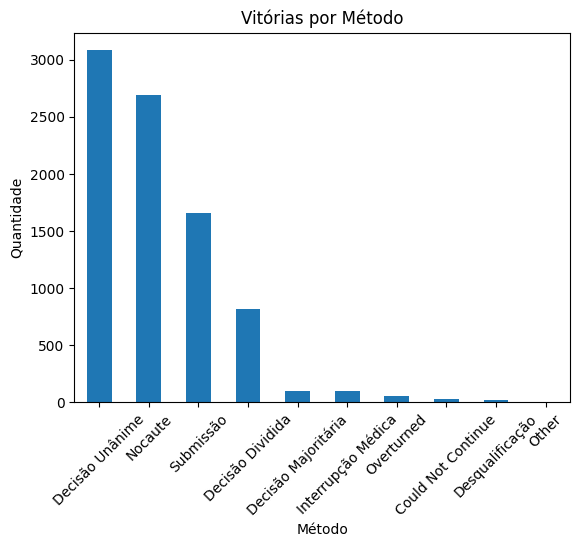

In [80]:
metodos = df['Metodo'].value_counts()

metodos.plot(kind='bar')
plt.title('Vitórias por Método')
plt.xlabel('Método')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.show()

**TOP 10 LUTADORES**

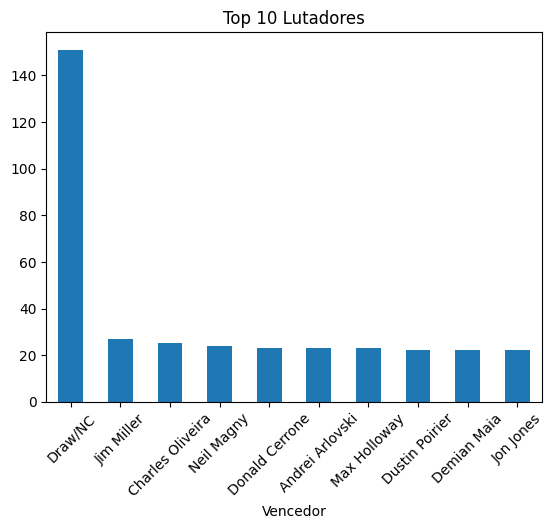

In [86]:
df['Vencedor'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Lutadores')
plt.xticks(rotation=45)
plt.show()

**TOP 5 CATEGORIAS COM MAIS LUTADORES**

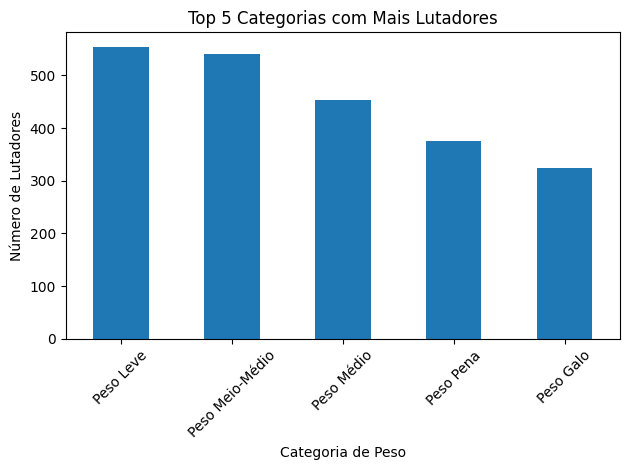

In [84]:
import pandas as pd
import matplotlib.pyplot as plt

lutadores = pd.concat([df['Lutador_1'], df['Lutador_2']])
categorias = pd.concat([df['Categoria_Peso'], df['Categoria_Peso']])

df_lutadores = pd.DataFrame({
    'Lutador': lutadores,
    'Categoria_Peso': categorias
})

contagem = df_lutadores.groupby('Categoria_Peso')['Lutador'].nunique()

top5 = contagem.sort_values(ascending=False).head(5)

top5.plot(kind='bar')

plt.title('Top 5 Categorias com Mais Lutadores')
plt.xlabel('Categoria de Peso')
plt.ylabel('Número de Lutadores')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()